In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df = pd.read_csv('Zomato_Data.csv')
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


In [4]:
def new_rate(value):
    a=value.split('/')
    b=a[0]
    return float(b)
df['rate']=df['rate'].apply(new_rate)
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining
144,New Indraprasta,No,No,3.3,0,150,Dining
145,Anna Kuteera,Yes,No,4.0,771,450,Dining
146,Darbar,No,No,3.0,98,800,Dining


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


## 01. What type of restaurant do the majority of customers order from?

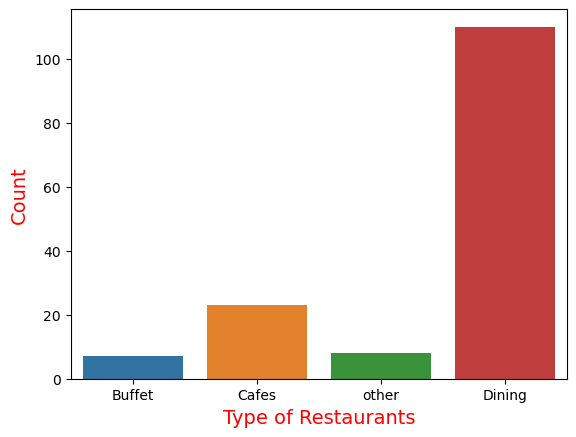

In [6]:
sns.countplot(x=df['listed_in(type)'])
plt.xlabel('Type of Restaurants',size=14,color='red')
plt.ylabel('Count',size=14,color='red')
plt.show()

### Conclusion-> Majority of customers order from the dining type of restaurant.

## 02. How many votes has each type of restaurant received from customers?

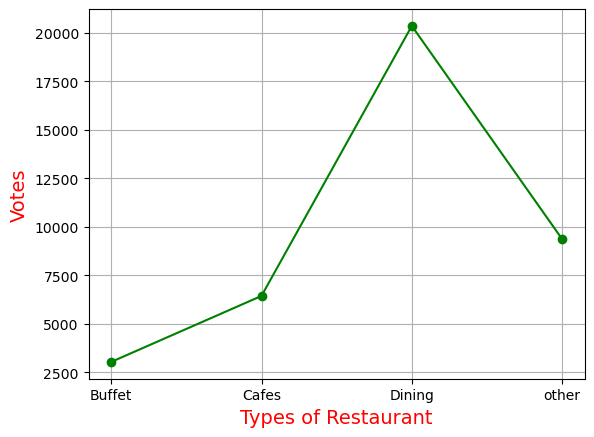

In [37]:
a = df.groupby('listed_in(type)')['votes'].sum()
b = pd.DataFrame({'votes': a})
plt.plot(b,marker='o',color='green')
plt.xlabel('Types of Restaurant',size=14,color='red')
plt.ylabel('Votes',size=14,color='red')
plt.grid()
plt.show()

## 03. What are the ratings that the majority of restaurants have received?

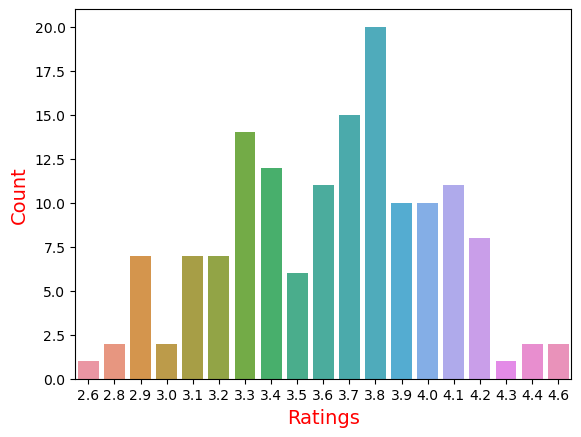

In [8]:
sns.countplot(x=df['rate'])
plt.xlabel('Ratings',size=14,color='red')
plt.ylabel('Count',size=14,color='red')
plt.show()

### Conclusion-> The majority of restaurants have received 3.8 ratings.

## 04. Zomato has observed that most couples order most of their food online. What is their average spending on each order?

In [25]:
a = df[df['online_order'] == 'Yes']['approx_cost(for two people)'].mean()
print(f"Average spending by couples on online orders: {a:.2f}")

Average spending by couples on online orders: 510.34


## 05. Which mode(online or offline) has received the maximum rating?

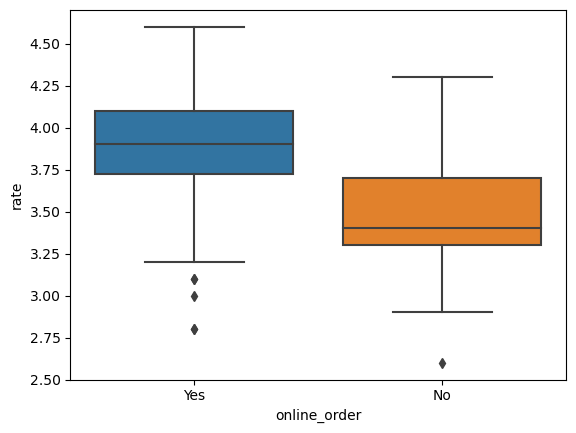

In [31]:
sns.boxplot(x=df['online_order'],y=df['rate'])
plt.show()

### Conclusion-> Online mode has received the maximum rating.

## 06. Which type of restaurant received more offline orders, so that Zomato can provide customers with some good offers?

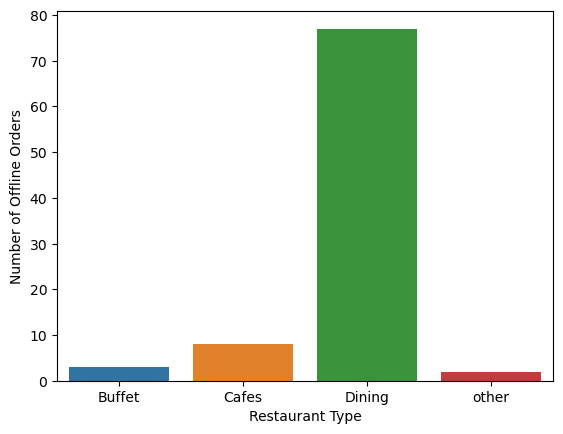

In [59]:
a = df[df['online_order']=='No'].groupby('listed_in(type)').size()
b = a.reset_index(name='count')
sns.barplot(x=b['listed_in(type)'], y=b['count'])
plt.xlabel('Restaurant Type')
plt.ylabel('Number of Offline Orders')
plt.show()

### Conclusion-> Dining type of restaurant received more offline orders.